# IIA - Trabajo Práctico 2 - Árboles de Decisión

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
from sklearn import tree as skltree
from sklearn import datasets as skldatasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import zero_one_loss

# Explorando el Iris Dataset

In [5]:
iris = skldatasets.load_iris()
print(iris.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [6]:
print("Data:")
print(iris.data[1:10])

print("Target:")
print(iris.target[1:10])

print("Target Names:")
print(iris.target_names)

print("Feature Names:")
print(iris.feature_names)

Data:
[[4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]]
Target:
[0 0 0 0 0 0 0 0 0]
Target Names:
['setosa' 'versicolor' 'virginica']
Feature Names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


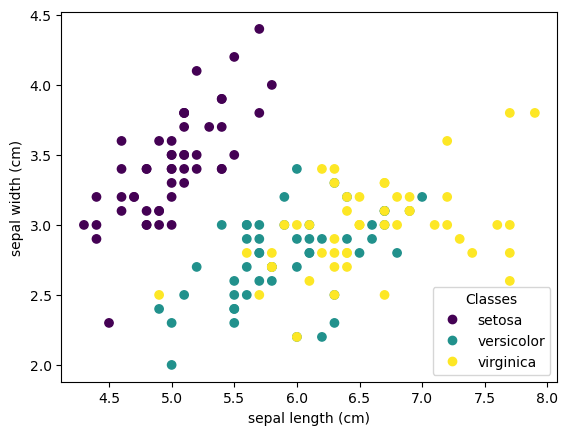

In [7]:
_, ax = plt.subplots()
scatter = ax.scatter(iris.data[:, 0], iris.data[:, 1], c=iris.target)
ax.set(xlabel=iris.feature_names[0], ylabel=iris.feature_names[1])
_ = ax.legend(
    scatter.legend_elements()[0], iris.target_names, loc="lower right", title="Classes"
)

## Clasificando Iris con Árboles de Decision

[[5.9 3.  4.2 1.5]
 [5.8 2.6 4.  1.2]
 [6.8 3.  5.5 2.1]
 [4.7 3.2 1.3 0.2]
 [6.9 3.1 5.1 2.3]
 [5.  3.5 1.6 0.6]
 [5.4 3.7 1.5 0.2]
 [5.  2.  3.5 1. ]
 [6.5 3.  5.5 1.8]
 [6.7 3.3 5.7 2.5]
 [6.  2.2 5.  1.5]
 [6.7 2.5 5.8 1.8]
 [5.6 2.5 3.9 1.1]
 [7.7 3.  6.1 2.3]
 [6.3 3.3 4.7 1.6]
 [5.5 2.4 3.8 1.1]
 [6.3 2.7 4.9 1.8]
 [6.3 2.8 5.1 1.5]
 [4.9 2.5 4.5 1.7]
 [6.3 2.5 5.  1.9]
 [7.  3.2 4.7 1.4]
 [6.5 3.  5.2 2. ]
 [6.  3.4 4.5 1.6]
 [4.8 3.1 1.6 0.2]
 [5.8 2.7 5.1 1.9]
 [5.6 2.7 4.2 1.3]
 [5.6 2.9 3.6 1.3]
 [5.5 2.5 4.  1.3]
 [6.1 3.  4.6 1.4]
 [7.2 3.2 6.  1.8]
 [5.3 3.7 1.5 0.2]
 [4.3 3.  1.1 0.1]
 [6.4 2.7 5.3 1.9]
 [5.7 3.  4.2 1.2]
 [5.4 3.4 1.7 0.2]
 [5.7 4.4 1.5 0.4]
 [6.9 3.1 4.9 1.5]
 [4.6 3.1 1.5 0.2]
 [5.9 3.  5.1 1.8]
 [5.1 2.5 3.  1.1]
 [4.6 3.4 1.4 0.3]
 [6.2 2.2 4.5 1.5]
 [7.2 3.6 6.1 2.5]
 [5.7 2.9 4.2 1.3]
 [4.8 3.  1.4 0.1]
 [7.1 3.  5.9 2.1]
 [6.9 3.2 5.7 2.3]
 [6.5 3.  5.8 2.2]
 [6.4 2.8 5.6 2.1]
 [5.1 3.8 1.6 0.2]
 [4.8 3.4 1.6 0.2]
 [6.5 3.2 5.1 2. ]
 [6.7 3.3 5.

[Text(0.375, 0.875, 'x[3] <= 0.8\nentropy = 1.581\nsamples = 112\nvalue = [37, 34, 41]'),
 Text(0.25, 0.625, 'entropy = 0.0\nsamples = 37\nvalue = [37, 0, 0]'),
 Text(0.3125, 0.75, 'True  '),
 Text(0.5, 0.625, 'x[2] <= 4.95\nentropy = 0.994\nsamples = 75\nvalue = [0, 34, 41]'),
 Text(0.4375, 0.75, '  False'),
 Text(0.25, 0.375, 'x[3] <= 1.55\nentropy = 0.414\nsamples = 36\nvalue = [0, 33, 3]'),
 Text(0.125, 0.125, 'entropy = 0.0\nsamples = 30\nvalue = [0, 30, 0]'),
 Text(0.375, 0.125, 'entropy = 1.0\nsamples = 6\nvalue = [0, 3, 3]'),
 Text(0.75, 0.375, 'x[3] <= 1.85\nentropy = 0.172\nsamples = 39\nvalue = [0, 1, 38]'),
 Text(0.625, 0.125, 'entropy = 0.503\nsamples = 9\nvalue = [0, 1, 8]'),
 Text(0.875, 0.125, 'entropy = 0.0\nsamples = 30\nvalue = [0, 0, 30]')]

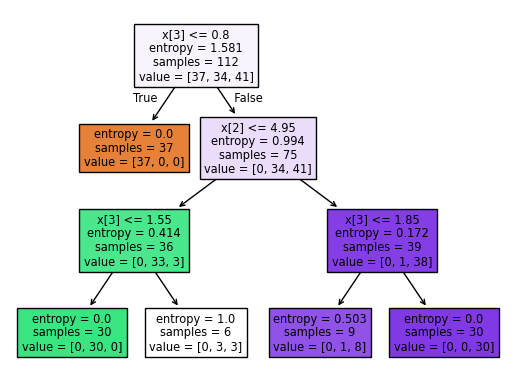

In [51]:
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
clf = skltree.DecisionTreeClassifier(criterion="entropy",min_impurity_decrease=0.002,random_state=0,min_samples_leaf=5)
clf.fit(X_train, y_train)
print(X_train)
print(y_train)

skltree.plot_tree(clf, filled=True)

### probando el árbol...

[[5.8 2.8 5.1 2.4]
 [6.  2.2 4.  1. ]
 [5.5 4.2 1.4 0.2]
 [7.3 2.9 6.3 1.8]
 [5.  3.4 1.5 0.2]
 [6.3 3.3 6.  2.5]
 [5.  3.5 1.3 0.3]
 [6.7 3.1 4.7 1.5]
 [6.8 2.8 4.8 1.4]
 [6.1 2.8 4.  1.3]
 [6.1 2.6 5.6 1.4]
 [6.4 3.2 4.5 1.5]
 [6.1 2.8 4.7 1.2]
 [6.5 2.8 4.6 1.5]
 [6.1 2.9 4.7 1.4]
 [4.9 3.6 1.4 0.1]
 [6.  2.9 4.5 1.5]
 [5.5 2.6 4.4 1.2]
 [4.8 3.  1.4 0.3]
 [5.4 3.9 1.3 0.4]
 [5.6 2.8 4.9 2. ]
 [5.6 3.  4.5 1.5]
 [4.8 3.4 1.9 0.2]
 [4.4 2.9 1.4 0.2]
 [6.2 2.8 4.8 1.8]
 [4.6 3.6 1.  0.2]
 [5.1 3.8 1.9 0.4]
 [6.2 2.9 4.3 1.3]
 [5.  2.3 3.3 1. ]
 [5.  3.4 1.6 0.4]
 [6.4 3.1 5.5 1.8]
 [5.4 3.  4.5 1.5]
 [5.2 3.5 1.5 0.2]
 [6.1 3.  4.9 1.8]
 [6.4 2.8 5.6 2.2]
 [5.2 2.7 3.9 1.4]
 [5.7 3.8 1.7 0.3]
 [6.  2.7 5.1 1.6]]


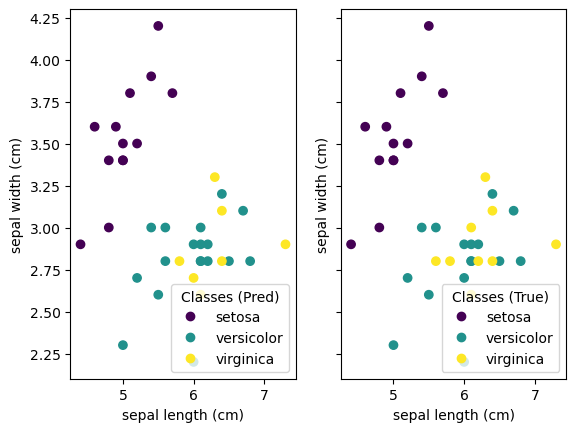

In [ ]:
y_predict = clf.predict(X_test)
_, ax = plt.subplots(1, 2, sharey=True)

scatter = ax[1].scatter(X_test[:,0], X_test[:,1], c=y_test)
ax[1].set(xlabel=iris.feature_names[0], ylabel=iris.feature_names[1])
_ = ax[1].legend(
    scatter.legend_elements()[0], iris.target_names, loc="lower right", title="Classes (True)"
)

scatter = ax[0].scatter(X_test[:,0], X_test[:,1], c=y_predict)
ax[0].set(xlabel=iris.feature_names[0], ylabel=iris.feature_names[1])
_ = ax[0].legend(
    scatter.legend_elements()[0], iris.target_names, loc="lower right", title="Classes (Pred)"
)

In [10]:
loss = zero_one_loss(y_test, y_predict)
print(f'Loss: {loss}')
print(f'Accuracy: {1-loss}')

Loss: 0.10526315789473684
Accuracy: 0.8947368421052632


# Ejercicios

## Ejercicio 1. Árboles en Espirales.


### Codigo para la generacion de espirales (Trabajo practico 2a).

In [76]:
def espirales(n: int) -> Tuple[np.ndarray, np.ndarray]:
    """
    Genera dos espirales entrelazadas con distribucion unfirome.
    """
    mid = n // 2
    
    def get_class_points(class_label: int, count: int) -> np.ndarray:
        points = []

        while len(points) < count:
            x = np.random.uniform(-1, 1, count)
            y = np.random.uniform(-1, 1, count)
            r = np.sqrt(x**2 + y**2)
            
            inside_circle = (r > 0) & (r <= 1)
            x, y, r = x[inside_circle], y[inside_circle], r[inside_circle]
            
            theta = np.arctan2(y, x)
            theta = np.where(theta < 0, theta + 2 * np.pi, theta)
            
            if class_label == 0:
                m1 = ((theta - 2*np.pi)/(4*np.pi) <= r) & (r <= (theta - np.pi)/(4*np.pi))
                m2 = (theta/(4*np.pi) <= r) & (r <= (theta + np.pi)/(4*np.pi))
                m3 = ((theta + 2*np.pi)/(4*np.pi) <= r) & (r <= (theta + 3*np.pi)/(4*np.pi))
                valid_mask = m1 | m2 | m3
            else:
                m1 = ((theta - np.pi)/(4*np.pi) <= r) & (r <= theta/(4*np.pi))
                m2 = ((theta + np.pi)/(4*np.pi) <= r) & (r <= (theta + 2*np.pi)/(4*np.pi))
                m3 = ((theta + 3*np.pi)/(4*np.pi) <= r) & (r <= (theta + 4*np.pi)/(4*np.pi))
                valid_mask = m1 | m2 | m3
                
            x_valid, y_valid = x[valid_mask], y[valid_mask]
            points.extend(np.column_stack((x_valid, y_valid)).tolist())
            
        return np.array(points[:count])

    X0 = get_class_points(class_label=0, count=mid)
    X1 = get_class_points(class_label=1, count=mid)
    
    X = np.vstack([X0, X1])
    y = np.concatenate((np.zeros(mid), np.ones(mid)))
    
    return X, y

### Conjunto de test.

In [77]:
testing_set_X, testing_set_y = espirales(10000)

### Entrenamos un arbol con 150 puntos y mostramos las predicciones respecto al conjunto real.

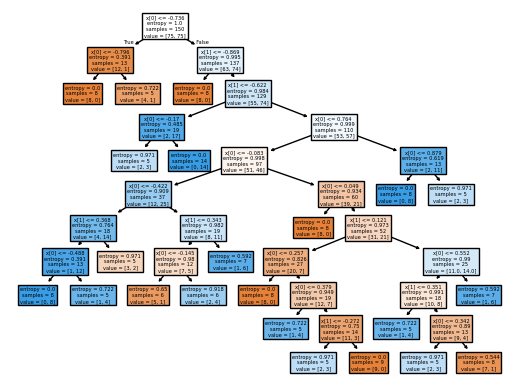

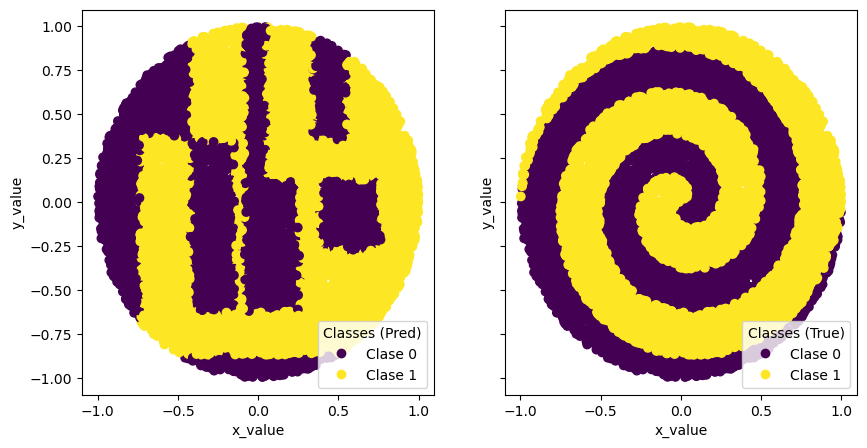

In [78]:
train_set_150_X,  train_set_150_y   = espirales(150)
clf = skltree.DecisionTreeClassifier(criterion="entropy",min_impurity_decrease=0.002,random_state=0,min_samples_leaf=5)
clf.fit(train_set_150_X, train_set_150_y)
skltree.plot_tree(clf, filled=True)

y_predict = clf.predict(testing_set_X)

_, ax = plt.subplots(1, 2, sharey=True, figsize=(10, 5))

scatter = ax[1].scatter(testing_set_X[:,0],testing_set_X[:,1], c=testing_set_y)
ax[1].set(xlabel="x_value", ylabel="y_value")
_ = ax[1].legend(
    scatter.legend_elements()[0], ["Clase 0","Clase 1"], loc="lower right", title="Classes (True)"
)

scatter = ax[0].scatter(testing_set_X[:,0],testing_set_X[:,1], c=y_predict)
ax[0].set(xlabel="x_value", ylabel="y_value")
_ = ax[0].legend(
    scatter.legend_elements()[0], ["Clase 0","Clase 1"], loc="lower right", title="Classes (Pred)"
)


### Entrenamos un arbol con 600 puntos y mostramos las predicciones respecto al conjunto real.

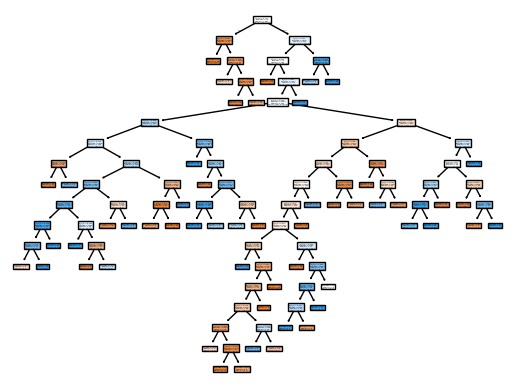

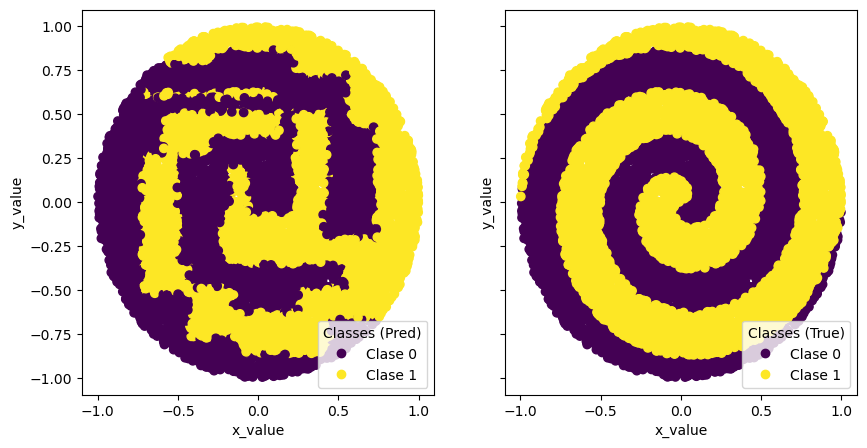

In [79]:
train_set_600_X,  train_set_600_y = espirales(600)
clf = skltree.DecisionTreeClassifier(criterion="entropy",min_impurity_decrease=0.002,random_state=0,min_samples_leaf=5)
clf.fit(train_set_600_X, train_set_600_y)
skltree.plot_tree(clf, filled=True)

y_predict = clf.predict(testing_set_X)

_, ax = plt.subplots(1, 2, sharey=True, figsize=(10, 5))

scatter = ax[1].scatter(testing_set_X[:,0],testing_set_X[:,1], c=testing_set_y)
ax[1].set(xlabel="x_value", ylabel="y_value")
_ = ax[1].legend(
    scatter.legend_elements()[0], ["Clase 0","Clase 1"], loc="lower right", title="Classes (True)"
)

scatter = ax[0].scatter(testing_set_X[:,0],testing_set_X[:,1], c=y_predict)
ax[0].set(xlabel="x_value", ylabel="y_value")
_ = ax[0].legend(
    scatter.legend_elements()[0], ["Clase 0","Clase 1"], loc="lower right", title="Classes (Pred)"
)

### Entrenamos un arbol con 3000 puntos y mostramos las predicciones respecto al conjunto real.

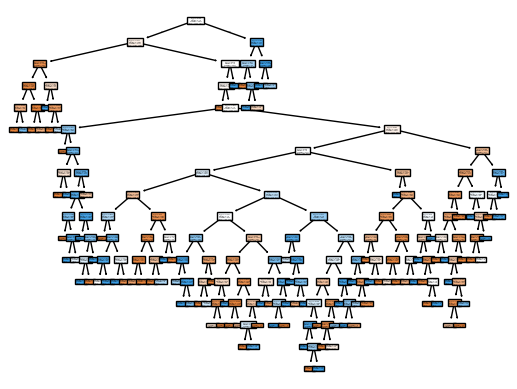

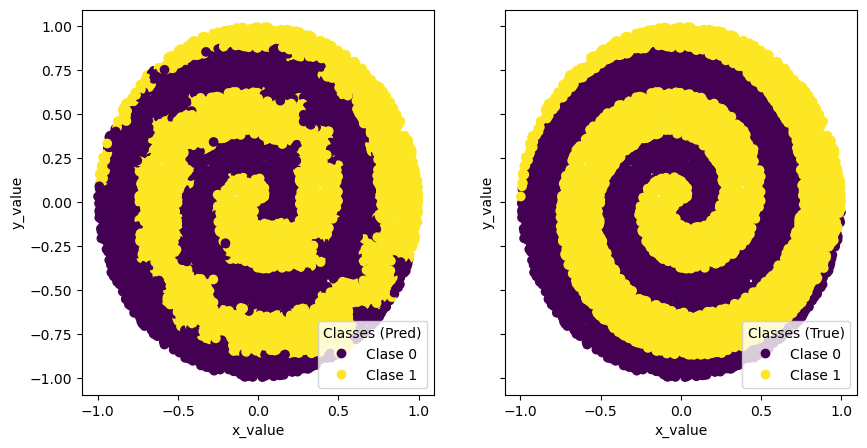

In [80]:
train_set_3000_X,  train_set_3000_y = espirales(3000)
clf = skltree.DecisionTreeClassifier(criterion="entropy",min_impurity_decrease=0.002,random_state=0,min_samples_leaf=5)
clf.fit(train_set_3000_X, train_set_3000_y)
skltree.plot_tree(clf, filled=True)

y_predict = clf.predict(testing_set_X)

_, ax = plt.subplots(1, 2, sharey=True, figsize=(10, 5))

scatter = ax[1].scatter(testing_set_X[:,0],testing_set_X[:,1], c=testing_set_y)
ax[1].set(xlabel="x_value", ylabel="y_value")
_ = ax[1].legend(
    scatter.legend_elements()[0], ["Clase 0","Clase 1"], loc="lower right", title="Classes (True)"
)

scatter = ax[0].scatter(testing_set_X[:,0],testing_set_X[:,1], c=y_predict)
ax[0].set(xlabel="x_value", ylabel="y_value")
_ = ax[0].legend(
    scatter.legend_elements()[0], ["Clase 0","Clase 1"], loc="lower right", title="Classes (Pred)"
)

## Ejercicio 2. Dependencia con la longitud del conjunto de entrenamiento - Sobreajuste.


## Ejercicio 3. Resistencia al ruido.

## Ejercicio 4. Dimensionalidad.

## Ejercicio 5. XOR. (Opcional, 1 punto).
